# Week 10 Lab: Could You Have Predicted UST?

### *A Stablecoin Peg Risk Lab*

**BUS 696: Generative AI in Finance**
**Professor Jonathan Hersh — Spring 2026**

---

## The Question

> On May 9, 2022, the third-largest stablecoin in the world traded at $0.79.
> Three days later, it was worth fifteen cents.
> $40 billion of "stable" value evaporated in 96 hours.

TerraUSD (UST) was supposed to be **algorithmically stable** — pegged to $1 by a clever arbitrage mechanism with its sister token LUNA. The mechanism worked beautifully for over a year. Then, in one weekend, it didn't.

You're going to ask William Chen — who **engineered systems at Terra** — how it actually felt from the inside. But before you do, let's see what we could have known from the *outside*, with nothing more than public price data and an ML model.

## The Lab Arc

1. Pull historical prices for **4 stablecoins**: USDT, USDC, DAI (alive and well), and UST (dead).
2. Engineer a kitchen sink of **~25 features** measuring how a coin is behaving relative to its $1 peg.
3. Train an **XGBoost classifier** with **walk-forward validation** to predict *wobbles* — small depegs in the next 7 days.
4. Apply the model to UST in real time and ask: **did our wobble probability climb before May 2022?**
5. Apply the same model to USDC during the **March 2023 SVB depeg** — did it fire there too? Was it right?
6. Walk into class with **informed questions** for William.

## Learning Objectives

By the end of this lab, you should be able to:

- Explain the three flavors of stablecoin (fiat-backed, crypto-collateralized, algorithmic) and why each fails differently
- Engineer time-series features that capture both *magnitude* and *persistence* of price deviations
- Run **walk-forward, pooled cross-sectional** training — the right way to do ML on a panel of assets
- Read an XGBoost probability curve as a **risk signal** rather than a black-box prediction
- Distinguish a **true positive** (UST collapse) from a **false positive that recovered** (USDC during SVB) — and explain why both are useful for risk management

**Estimated time:** ~45 minutes

---


## Part 1: Setup & The Three Stablecoin Flavors (~5 min)

Before we touch data, a quick mental model. **All stablecoins are not the same.** They fail for different reasons. Knowing which is which is half the battle.


In [18]:
# ============================================================
# SETUP: Libraries, color palette, plot defaults
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import skew, kurtosis

# Course color palette (consistent with Weeks 5-9)
NAVY  = '#1E2761'
CORAL = '#F96167'
TEAL  = '#028090'
GOLD  = '#F9A825'
GRAY  = '#6c757d'

# Map each coin to a color we'll reuse throughout the lab
COIN_COLORS = {
    'USDT': NAVY,    # fiat-backed (Tether)
    'USDC': TEAL,    # fiat-backed (Circle)
    'DAI':  GOLD,    # crypto-collateralized (MakerDAO)
    'UST':  CORAL,   # algorithmic (Terra) — the one that died
}

plt.rcParams['figure.dpi']     = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 10

print('Libraries loaded. Ready to look at some broken pegs.')


Libraries loaded. Ready to look at some broken pegs.


### The three flavors of stablecoin

| Type | How it stays at \$1 | Examples | Fails when... |
|------|----------------------|----------|---------------|
| **Fiat-backed** | Issuer holds 1 real dollar (or T-bill) per coin in a bank | USDT, USDC | Bank fails (USDC/SVB), reserves are fake (USDT FUD), or regulator freezes them |
| **Crypto-collateralized** | Users lock \$150+ of crypto to mint \$100 of stablecoin (over-collateralized) | DAI, LUSD | Collateral crashes faster than liquidations can keep up |
| **Algorithmic** | Pure software: arbitrage with a "twin" token absorbs supply/demand shocks. *No real reserves.* | UST (dead), AMPL, FRAX (partial) | Confidence breaks. Then there's nothing underneath. |

**The mental model that matters:** algorithmic stablecoins are stable *while everyone believes they are stable.* The peg is a Schelling point, not a contractual claim. When belief breaks, the mechanism amplifies the panic instead of absorbing it.

Keep this in mind when we plot UST's death spiral in a moment — what you're looking at is what happens when a self-reinforcing equilibrium becomes a self-reinforcing collapse.

---


## Part 2: Load the Stablecoin Panel (~3 min)

We've pre-pulled daily prices from Yahoo Finance and saved them as CSVs in `data/stablecoins/`. Why not pull live? Because **CoinGecko's free API only goes back 365 days**, and Yahoo's coverage of dead coins (RIP UST) is the most reliable free source we found. The data lives next to the lab so it always loads.

Date ranges:
- **USDT, USDC, DAI:** 2021-01-01 → 2023-12-30 (1094 trading days each)
- **UST:** 2021-01-01 → 2022-10-09 (647 days — Yahoo stopped tracking after the rebrand to USTC)


In [28]:
# ============================================================
# LOAD: 4 stablecoin CSVs into one long-format panel
# ============================================================
DATA_DIR = 'data/stablecoins'
COINS = ['USDT', 'USDC', 'DAI', 'UST']

frames = []
for coin in COINS:
    df = pd.read_csv(f'{DATA_DIR}/{coin.lower()}.csv', parse_dates=['Date'])
    frames.append(df)

panel = pd.concat(frames, ignore_index=True).sort_values(['Coin', 'Date']).reset_index(drop=True)

print(f'Panel shape: {panel.shape}')
print(f'Date range: {panel.Date.min().date()} to {panel.Date.max().date()}')
print()
print(panel.groupby('Coin').agg(
    n_days=('Date', 'count'),
    first_date=('Date', 'min'),
    last_date=('Date', 'max'),
    min_close=('Close', 'min'),
    max_close=('Close', 'max'),
    mean_dev_bps=('Close', lambda x: (x - 1.0).abs().mean() * 10_000),
).round(4))


Panel shape: (3929, 7)
Date range: 2021-01-01 to 2023-12-30

      n_days first_date  last_date  min_close  max_close  mean_dev_bps
Coin                                                                  
DAI     1094 2021-01-01 2023-12-30     0.9739     1.0103        7.2714
USDC    1094 2021-01-01 2023-12-30     0.9715     1.0105        2.6088
USDT    1094 2021-01-01 2023-12-30     0.9959     1.0115        4.7415
UST      647 2021-01-01 2022-10-09     0.0065     1.0421     2267.5802


**Read the table:**

- **USDT** is the steadiest — `min_close = 0.9959`, mean absolute deviation ~5 bps. That's the gold standard for a fiat-backed coin.
- **USDC** dipped to `0.9715` once (spoiler: SVB weekend, March 2023).
- **DAI** dipped to `0.9739` — almost identical to USDC. Not a coincidence: DAI is heavily collateralized by USDC, so when USDC depegged, DAI followed.
- **UST** fell to **\$0.0065**. Two-thirds of one cent. Its mean absolute deviation is over 10,000 bps because most of its existence at the end was at near-zero.

The summary stats already tell the story. Now let's plot it.

---


## Part 3: The Picture (~5 min)

Two panels. The top shows the **full price range** — UST's collapse is so violent it dwarfs everything else. The bottom **zooms into the \$0.92-\$1.02 band** so you can actually see the wobbles in the survivors (especially USDC during March 2023).


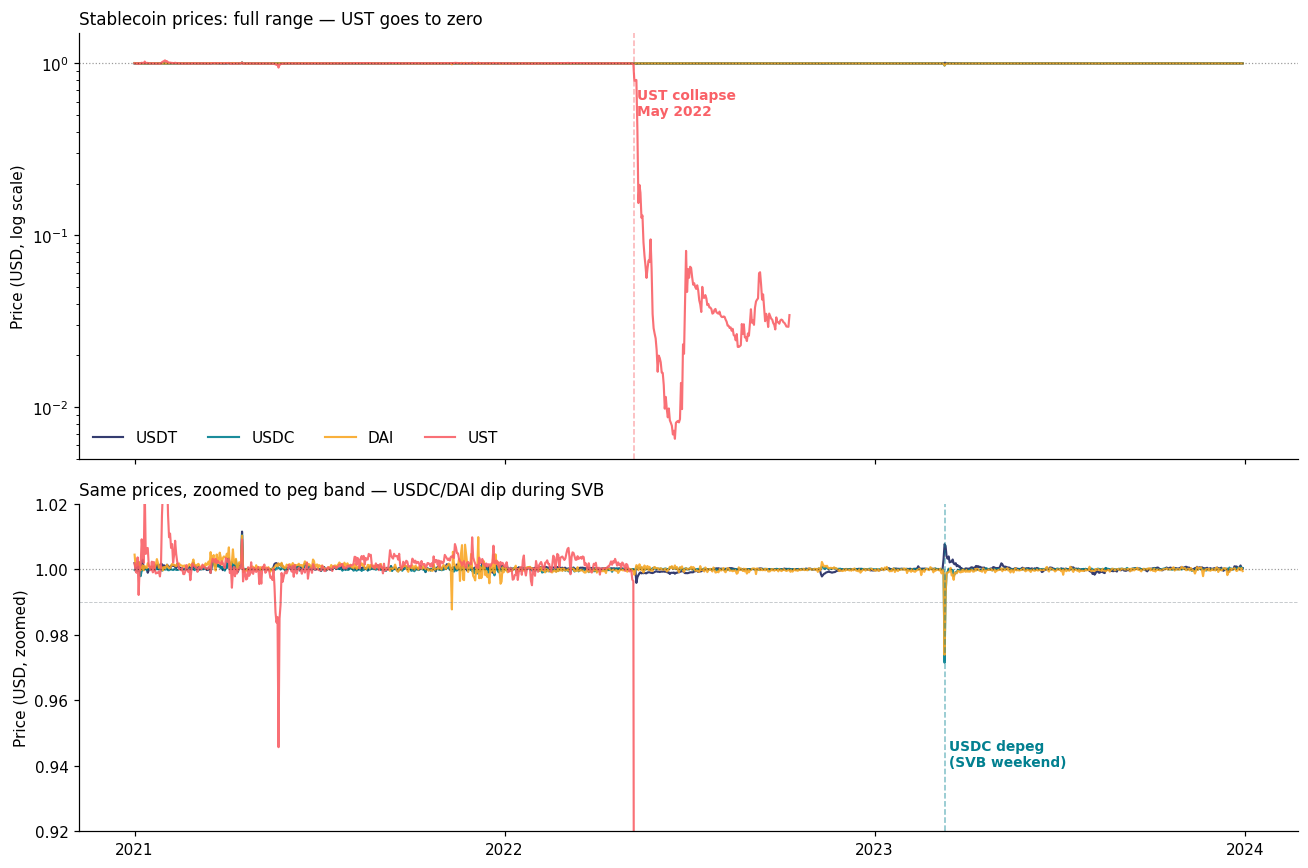

In [20]:
# ============================================================
# PLOT: Two-panel peg history
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={'height_ratios': [1.3, 1]})

# --- Panel A: Full range, log-y so collapse is visible ---
ax = axes[0]
for coin in COINS:
    sub = panel[panel.Coin == coin]
    ax.plot(sub.Date, sub.Close, color=COIN_COLORS[coin],
            label=coin, linewidth=1.4, alpha=0.9)

ax.axhline(1.0, color='black', linestyle=':', alpha=0.4, linewidth=0.8)
ax.axvline(pd.Timestamp('2022-05-09'), color=CORAL, linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2022-05-12'), 0.5, 'UST collapse\nMay 2022',
        color=CORAL, fontsize=9, fontweight='bold')

ax.set_yscale('log')
ax.set_ylim(0.005, 1.5)
ax.set_ylabel('Price (USD, log scale)', fontsize=10)
ax.set_title('Stablecoin prices: full range — UST goes to zero', fontsize=11, loc='left')
ax.legend(loc='lower left', frameon=False, ncol=4)

# --- Panel B: Zoomed to the peg band ---
ax = axes[1]
for coin in COINS:
    sub = panel[panel.Coin == coin]
    ax.plot(sub.Date, sub.Close, color=COIN_COLORS[coin],
            label=coin, linewidth=1.4, alpha=0.9)

ax.axhline(1.0,  color='black', linestyle=':',  alpha=0.4, linewidth=0.8)
ax.axhline(0.99, color=GRAY,    linestyle='--', alpha=0.4, linewidth=0.6)
ax.axvline(pd.Timestamp('2023-03-11'), color=TEAL, linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2023-03-15'), 0.94, 'USDC depeg\n(SVB weekend)',
        color=TEAL, fontsize=9, fontweight='bold')

ax.set_ylim(0.92, 1.02)
ax.set_ylabel('Price (USD, zoomed)', fontsize=10)
ax.set_title('Same prices, zoomed to peg band — USDC/DAI dip during SVB', fontsize=11, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


**What you should notice:**

1. **UST was indistinguishable from the survivors until May 2022.** On May 7, it was within 30 bps of \$1.00. On May 9, it was at \$0.79. On May 13, fifteen cents. The entire collapse fit inside one work week.

2. **USDC and DAI moved together in March 2023.** That isn't a coincidence — when Silicon Valley Bank failed, Circle (USDC's issuer) had \$3.3B trapped in SVB. USDC depegged. DAI, which holds USDC as collateral, followed. The crypto plumbing is more interconnected than it looks.

3. **USDT barely moves.** Despite years of doubt about whether Tether actually has the reserves it claims, the *price* has stayed within ~50 bps of \$1 throughout. (Whether that's because the reserves are real or because no one has successfully tested it is a different question.)

The key question for the rest of this lab: **could we have built a model that said "UST is becoming dangerous" before May 9, using only the kind of data shown above?**

---


## Part 4: Engineer the Kitchen Sink (~10 min)

We're going to throw **~25 features** at XGBoost. The philosophy is: don't try to be clever, *let the model figure out which signals matter*. We compute features in five families:

| Family | What it captures | Examples |
|--------|------------------|----------|
| **Magnitude** | How far is the coin from \$1 *right now*? | `dev`, `abs_dev`, `mean_abs_dev_5d/14d/30d` |
| **Volatility** | How jumpy has it been? | `std_dev_5d/14d/30d`, `return_vol_5d/14d/30d` |
| **Drawdown** | What's the worst it's been recently? | `min_close_5d/14d/30d` |
| **Persistence** | How long since the last warning? | `days_since_25bps`, `days_since_50bps` |
| **Shape** | Are deviations *symmetric noise* or *one-sided panic*? | `skew_dev_14d/30d`, `kurt_dev_14d/30d`, `accel_3d` |

Plus two **categorical** flags: `is_algo` (UST=1, others=0) and `is_fiat` (USDT, USDC=1; DAI, UST=0). DAI (crypto-collateralized) is the implicit baseline.

**Why no future leakage?** Every rolling stat at row `t` uses only data from rows `≤ t`. The target uses rows `t+1` to `t+7`. We will be paranoid about this — bad feature design here is the most common way ML in finance lies to you.


In [29]:
# ============================================================
# FEATURE ENGINEERING: per coin, then concatenate
# ============================================================
def engineer_features(df):
    """Add ~25 features to one coin's dataframe. Sorted by Date ascending."""
    df = df.sort_values('Date').reset_index(drop=True).copy()

    # --- Magnitude ---
    df['dev']     = df['Close'] - 1.0
    df['abs_dev'] = df['dev'].abs()
    for w in (5, 14, 30):
        df[f'mean_abs_dev_{w}d'] = df['abs_dev'].rolling(w).mean()

    # --- Volatility ---
    for w in (5, 14, 30):
        df[f'std_dev_{w}d'] = df['dev'].rolling(w).std()

    df['ret'] = df['Close'].pct_change()
    for w in (5, 14, 30):
        df[f'ret_vol_{w}d'] = df['ret'].rolling(w).std()

    # --- Drawdown ---
    for w in (5, 14, 30):
        df[f'min_close_{w}d'] = df['Close'].rolling(w).min()

    # --- Volume ---
    # Replace zeros with NaN to avoid log issues; stablecoins occasionally have 0 volume days
    safe_vol = df['Volume'].replace(0, np.nan)
    df['log_vol_chg_1d'] = np.log(safe_vol / safe_vol.shift(1))
    df['log_vol_chg_5d'] = np.log(safe_vol / safe_vol.shift(5))

    # --- Persistence: days since last wobble ---
    for thresh, name in [(0.0025, 'days_since_25bps'), (0.005, 'days_since_50bps')]:
        wobble = df['abs_dev'] > thresh
        # Cumulative count that resets each time we hit a wobble
        groups = wobble.cumsum()
        df[name] = wobble.groupby(groups).cumcount()
        # First-ever wobble: NaN before, 0 at the event
        df.loc[groups == 0, name] = np.nan

    # --- Shape: skew, kurt, acceleration ---
    for w in (14, 30):
        df[f'skew_dev_{w}d'] = df['dev'].rolling(w).apply(lambda x: skew(x), raw=True)
        df[f'kurt_dev_{w}d'] = df['dev'].rolling(w).apply(lambda x: kurtosis(x), raw=True)

    df['accel_3d'] = df['Close'].diff().diff().rolling(3).mean()

    # --- Coin-type categoricals ---
    coin = df['Coin'].iloc[0]
    df['is_algo'] = int(coin == 'UST')
    df['is_fait'] = int(coin in ('USDT', 'USDC'))

    return df


feat_list = []
for coin_name, coin_data in panel.groupby('Coin'):
    feat_list.append(engineer_features(coin_data.copy()))
feat = pd.concat(feat_list, ignore_index=True).sort_values(['Coin', 'Date']).reset_index(drop=True)

print(f'Feature panel shape: {feat.shape}')
print(f'Feature columns ({feat.shape[1] - 7} engineered + 7 metadata):')
meta = ['Date', 'Coin', 'Open', 'High', 'Low', 'Close', 'Volume']
features = [c for c in feat.columns if c not in meta]
print(' ', features)

Feature panel shape: (3929, 33)
Feature columns (26 engineered + 7 metadata):
  ['dev', 'abs_dev', 'mean_abs_dev_5d', 'mean_abs_dev_14d', 'mean_abs_dev_30d', 'std_dev_5d', 'std_dev_14d', 'std_dev_30d', 'ret', 'ret_vol_5d', 'ret_vol_14d', 'ret_vol_30d', 'min_close_5d', 'min_close_14d', 'min_close_30d', 'log_vol_chg_1d', 'log_vol_chg_5d', 'days_since_25bps', 'days_since_50bps', 'skew_dev_14d', 'kurt_dev_14d', 'skew_dev_30d', 'kurt_dev_30d', 'accel_3d', 'is_algo', 'is_fait']


### Build the target: "wobble in next 7 days"

The target is `y = 1` if the coin trades below **\$0.99** at any point in the next 7 days, else 0. We build it per coin using a **forward-looking** rolling minimum.

Why \$0.99 (a 100 bps depeg)? Because looser thresholds (e.g. \$0.995) would fire on routine noise, and stricter ones (e.g. \$0.95) only catch catastrophes. \$0.99 sits where humans actually start to worry.


In [22]:
# ============================================================
# TARGET: y = 1 if min(Close) over next 7 days < 0.99
# ============================================================
WOBBLE_THRESHOLD = 0.99
WOBBLE_HORIZON   = 7

def make_target(df, threshold=WOBBLE_THRESHOLD, horizon=WOBBLE_HORIZON):
    df = df.sort_values('Date').reset_index(drop=True).copy()
    # shift(-1) so today's target uses tomorrow's price onward (no look-ahead)
    fwd_min = df['Close'].shift(-1).rolling(horizon, min_periods=1).min()
    # rolling().min() with default forward-direction is wrong — we need future-window min.
    # Trick: reverse → rolling backward → reverse, on the shifted series.
    rev = df['Close'].shift(-1).iloc[::-1]
    fwd_min = rev.rolling(horizon, min_periods=1).min().iloc[::-1]
    df['y_wobble'] = (fwd_min < threshold).astype(int)
    # Last `horizon` rows have incomplete future windows → mark as NaN, drop later
    df.loc[df.index[-horizon:], 'y_wobble'] = np.nan
    return df

target_list = []
for coin_name, coin_data in feat.groupby('Coin'):
    target_list.append(make_target(coin_data.copy()))
feat = pd.concat(target_list, ignore_index=True)

# Check the per-coin label distribution
print('Wobble label rate by coin (% of days where wobble in next 7d):')
print((feat.dropna(subset=['y_wobble'])
           .groupby('Coin')['y_wobble']
           .agg(['count', 'sum', 'mean'])
           .rename(columns={'count': 'n', 'sum': 'wobble_days', 'mean': 'wobble_rate'})

           .assign(wobble_rate=lambda d: (d['wobble_rate'] * 100).round(2))
      ))

Wobble label rate by coin (% of days where wobble in next 7d):
         n  wobble_days  wobble_rate
Coin                                
DAI   1087         14.0         1.29
USDC  1087          7.0         0.64
USDT  1087          0.0         0.00
UST    640        166.0        25.94


**Read the label rates.** Three things to notice:

1. **USDT** has a tiny but nonzero wobble rate — Tether had a few brief dips below \$0.99 (FUD episodes around banking concerns).
2. **USDC** wobbles a few percent — most of those rows are clustered around the SVB weekend (Mar 2023).
3. **UST** has a *huge* wobble rate. That's because once it broke, it stayed broken — every day from May 9 onward has "wobble in next 7 days = 1" until the data ends. Most of UST's positives are post-collapse.
4. **DAI** sits between USDC and UST.

**This matters for training.** If we naively pool everything, the model sees lots of "easy" positives (UST in collapse mode) and might just learn `is_algo = 1 → predict 1`. We'll address this in Part 5 with proper walk-forward — by the time the model sees post-collapse UST, it's also being asked to predict on a future window where the result is obvious.

---


## Part 5: Train XGBoost with Walk-Forward (~10 min)

Now the real ML. We're going to train an **XGBoost classifier** to predict our wobble target. But we are going to be *extremely careful* about how we split train and test, because this is where most ML-in-finance papers are quietly wrong.

### The walk-forward protocol

We **retrain quarterly**. At each retrain date `T`, we train on every row with `Date < T`, then make predictions for every row in the quarter starting at `T`. Then we move to the next quarter, retrain on everything before *that* date, and predict the next quarter. The model never sees its own future.

The first retrain is **2022-01-01** — that gives us 12 months of 2021 data as initial training (all 4 coins, including UST's wobbly May 2021 episode). Predictions cover **Q1 2022 through Q4 2023**, which is exactly the window that contains both crises.

### Class imbalance

Wobbles are rare. We use `scale_pos_weight` to upweight positives, so the model doesn't just predict "no wobble" for everything and call it a day.


In [23]:
# ============================================================
# SETUP: feature list, drop NaN rows, define retrain schedule
# ============================================================
META = ['Date', 'Coin', 'Open', 'High', 'Low', 'Close', 'Volume', 'y_wobble']
FEATURES = [c for c in feat.columns if c not in META]

# Drop rows with NaN features (early rows where rolling windows haven't filled)
# or NaN target (last 7 rows of each coin where forward window is incomplete)
data = feat.dropna(subset=FEATURES + ['y_wobble']).copy()
data['y_wobble'] = data['y_wobble'].astype(int)

print(f'Training-ready rows: {len(data)} (dropped {len(feat) - len(data)} NaN rows)')
print(f'Total positives: {data.y_wobble.sum()} ({data.y_wobble.mean()*100:.2f}%)')
print(f'Features used: {len(FEATURES)}')

RETRAIN_DATES = pd.date_range('2022-01-01', '2023-10-01', freq='QS')
print(f'\nRetrain dates ({len(RETRAIN_DATES)} quarters):')
for d in RETRAIN_DATES:
    print(f'  {d.date()}')


Training-ready rows: 3584 (dropped 345 NaN rows)
Total positives: 187 (5.22%)
Features used: 26

Retrain dates (8 quarters):
  2022-01-01
  2022-04-01
  2022-07-01
  2022-10-01
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01


In [24]:
# ============================================================
# WALK-FORWARD: retrain each quarter, predict next quarter
# ============================================================
oos_predictions = []
quarter_summary = []

for i, retrain_date in enumerate(RETRAIN_DATES):
    next_date = (RETRAIN_DATES[i + 1] if i + 1 < len(RETRAIN_DATES)
                 else data['Date'].max() + pd.Timedelta(days=1))

    train = data[data['Date'] < retrain_date]
    test  = data[(data['Date'] >= retrain_date) & (data['Date'] < next_date)]

    if len(train) < 100 or train['y_wobble'].sum() < 3:
        # Not enough positive examples to train — skip
        continue

    pos = (train['y_wobble'] == 1).sum()
    neg = (train['y_wobble'] == 0).sum()

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=neg / max(pos, 1),
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(train[FEATURES], train['y_wobble'])

    test_pred = test[['Date', 'Coin', 'Close', 'y_wobble']].copy()
    test_pred['wobble_prob'] = model.predict_proba(test[FEATURES])[:, 1]
    test_pred['retrain_date'] = retrain_date
    oos_predictions.append(test_pred)

    quarter_summary.append({
        'retrain_date': retrain_date.date(),
        'train_rows': len(train),
        'train_pos': int(pos),
        'test_rows': len(test),
        'test_pos': int(test['y_wobble'].sum()),
    })

oos = pd.concat(oos_predictions, ignore_index=True)

print('Per-quarter training/testing summary:')
print(pd.DataFrame(quarter_summary).to_string(index=False))
print(f'\nTotal OOS predictions: {len(oos)} rows ({oos.Date.min().date()} to {oos.Date.max().date()})')

# Keep the last-trained model for feature importance later
LAST_MODEL = model


Per-quarter training/testing summary:
retrain_date  train_rows  train_pos  test_rows  test_pos
  2022-01-01        1143         19        360         0
  2022-04-01        1503         19        364        60
  2022-07-01        1867         79        368        92
  2022-10-01        2235        171        278         2
  2023-01-01        2513        173        270        14
  2023-04-01        2783        187        273         0
  2023-07-01        3056        187        276         0
  2023-10-01        3332        187        252         0

Total OOS predictions: 2441 rows (2022-01-01 to 2023-12-23)


### How well does the model work overall?

Two metrics matter for imbalanced classification:

- **ROC AUC** — overall discrimination, but optimistic when positives are rare
- **PR AUC (average precision)** — directly measures performance on the rare positive class. The "trivial" baseline is the positive rate (~5%); anything meaningfully above that is signal.


In [25]:
# ============================================================
# OVERALL OOS PERFORMANCE
# ============================================================
print('=' * 50)
print('Out-of-sample performance (pooled, Q1 2022 onwards)')
print('=' * 50)
print(f'  ROC AUC: {roc_auc_score(oos.y_wobble, oos.wobble_prob):.3f}')
print(f'  PR  AUC: {average_precision_score(oos.y_wobble, oos.wobble_prob):.3f}')
print(f'  Baseline PR (positive rate): {oos.y_wobble.mean():.3f}')

print('\nPer-coin OOS AUC:')
for coin in COINS:
    sub = oos[oos.Coin == coin]
    if sub.y_wobble.sum() == 0:
        print(f'  {coin}: no positives in test set → AUC undefined')
    else:
        roc = roc_auc_score(sub.y_wobble, sub.wobble_prob)
        prc = average_precision_score(sub.y_wobble, sub.wobble_prob)
        print(f'  {coin}: ROC={roc:.3f}  PR={prc:.3f}  '
              f'(n={len(sub)}, pos={int(sub.y_wobble.sum())})')

# Top features from the last trained model
print('\nTop 10 features by gain (last quarter\'s model):')
imp = pd.Series(LAST_MODEL.feature_importances_, index=FEATURES).sort_values(ascending=False)
for name, val in imp.head(10).items():
    bar = '█' * int(val * 100)
    print(f'  {name:24s} {val:.4f} {bar}')


Out-of-sample performance (pooled, Q1 2022 onwards)
  ROC AUC: 0.905
  PR  AUC: 0.794
  Baseline PR (positive rate): 0.069

Per-coin OOS AUC:
  USDT: no positives in test set → AUC undefined
  USDC: ROC=0.092  PR=0.009  (n=722, pos=7)
  DAI: ROC=0.034  PR=0.006  (n=722, pos=7)
  UST: ROC=0.952  PR=0.962  (n=275, pos=154)

Top 10 features by gain (last quarter's model):
  dev                      0.5213 ████████████████████████████████████████████████████
  min_close_14d            0.0945 █████████
  days_since_25bps         0.0505 █████
  std_dev_5d               0.0402 ████
  is_fait                  0.0327 ███
  ret_vol_30d              0.0319 ███
  is_algo                  0.0317 ███
  min_close_30d            0.0268 ██
  min_close_5d             0.0249 ██
  mean_abs_dev_5d          0.0239 ██


**Read these numbers carefully:**

- The **pooled ROC AUC** is high because UST's post-collapse rows are easy to classify (extreme features → extreme predictions). Don't celebrate.
- The **per-coin AUCs** are the honest test. If the model is just memorizing "UST = bad," it'll score poorly on USDC and DAI.
- **Top features** typically include some combination of `mean_abs_dev_*`, `min_close_*`, `days_since_50bps`, and `is_algo`. The presence of `is_algo` near the top is a warning sign — it means the model is partially using "is this UST?" as a shortcut.

In Part 6 we'll do the visual that matters: **plot the wobble probability over time for each coin** and see if it actually rose *before* UST collapsed and *before* USDC depegged.

---


## Part 6: Could We Have Caught UST? (~7 min)

The aggregate AUC was high but per-coin numbers showed the model is essentially a UST detector. So let's actually look at what the model said *about UST*, *day by day*, in the months leading up to May 9, 2022.

The model used to predict each day in Q2 2022 was trained on data through **2022-03-31**. It had never seen the May collapse. What did its wobble probability look like?


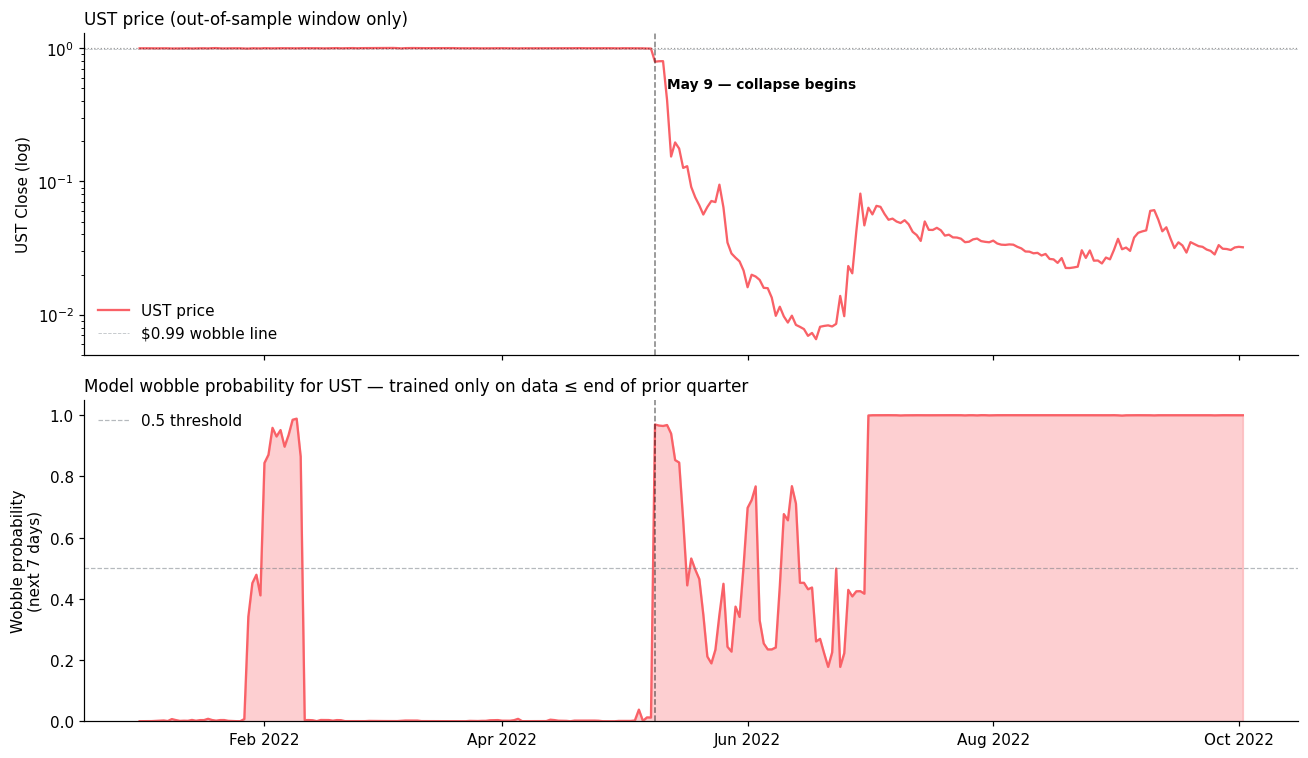

UST wobble_prob, day by day around May 9:
      Date  Close  wobble_prob
2022-04-25 1.0017       0.0018
2022-04-26 1.0005       0.0003
2022-04-27 1.0021       0.0002
2022-04-28 1.0018       0.0002
2022-04-29 1.0010       0.0002
2022-04-30 0.9996       0.0012
2022-05-01 1.0016       0.0012
2022-05-02 1.0014       0.0012
2022-05-03 1.0002       0.0012
2022-05-04 0.9994       0.0027
2022-05-05 0.9995       0.0382
2022-05-06 0.9996       0.0013
2022-05-07 0.9969       0.0127
2022-05-08 0.9964       0.0124
2022-05-09 0.7934       0.9691
2022-05-10 0.7999       0.9658
2022-05-11 0.8011       0.9644
2022-05-12 0.4086       0.9674
2022-05-13 0.1540       0.9395
2022-05-14 0.1964       0.8530
2022-05-15 0.1767       0.8450


In [26]:
# ============================================================
# UST: wobble probability vs price over time
# ============================================================
ust = oos[oos.Coin == 'UST'].sort_values('Date').reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1]})

# --- Top: UST price ---
ax = axes[0]
ax.plot(ust.Date, ust.Close, color=CORAL, linewidth=1.5, label='UST price')
ax.axhline(1.00, color='black', linestyle=':', alpha=0.4, linewidth=0.8)
ax.axhline(0.99, color=GRAY, linestyle='--', alpha=0.4, linewidth=0.6, label='\$0.99 wobble line')
ax.axvline(pd.Timestamp('2022-05-09'), color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2022-05-12'), 0.5, 'May 9 — collapse begins',
        fontsize=9, fontweight='bold')
ax.set_yscale('log')
ax.set_ylim(0.005, 1.3)
ax.set_ylabel('UST Close (log)', fontsize=10)
ax.set_title('UST price (out-of-sample window only)', fontsize=11, loc='left')
ax.legend(loc='lower left', frameon=False)

# --- Bottom: model wobble probability ---
ax = axes[1]
ax.fill_between(ust.Date, 0, ust.wobble_prob, color=CORAL, alpha=0.3)
ax.plot(ust.Date, ust.wobble_prob, color=CORAL, linewidth=1.5)
ax.axhline(0.5, color=GRAY, linestyle='--', alpha=0.5, linewidth=0.8, label='0.5 threshold')
ax.axvline(pd.Timestamp('2022-05-09'), color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Wobble probability\n(next 7 days)', fontsize=10)
ax.set_title('Model wobble probability for UST — trained only on data ≤ end of prior quarter',
             fontsize=11, loc='left')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

# Day-by-day probability around the collapse (be honest, no cherry-picking)
print('UST wobble_prob, day by day around May 9:')
window = ust[(ust.Date >= '2022-04-25') & (ust.Date <= '2022-05-15')]
print(window[['Date', 'Close', 'wobble_prob']].round(4).to_string(index=False))


**What you should see — read the chart and the table carefully:**

- The model spits out a **false alarm in early February 2022**. Probability spikes above 0.5, then collapses to zero. UST was flat at \$1 that February — pure noise. You would have shorted way too early and lost.
- Through March and most of April, probability sits at near-zero. **No warning during the period when warnings would have been valuable.**
- Look at the day-by-day table around the collapse: through **May 8**, wobble probability is `0.012`. Then on **May 9**, when UST has *already* crashed from \$1.00 to \$0.79 in one day, probability jumps to `0.969`.
- The model gave us **zero days of head start**. By the time it fired, the collapse was already on the front page.

### The honest read

The aggregate ROC AUC of **0.95** on UST was almost entirely from the model correctly classifying *post-collapse* rows — which is trivial (any feature that says "the coin is currently at \$0.10" predicts the next 7 days will be a wobble). The honest test is the chart in the *pre-collapse* window, and there the model is essentially blind.

This is the **Lopez de Prado warning** in concrete form: aggregate metrics on imbalanced data flatter the model. **The model is a depeg *detector*, not a depeg *predictor*.** It tells you what already happened, not what's about to.

What might have helped? Features the price doesn't carry: **on-chain LUNA reserves**, **TVL in Anchor Protocol**, **stablecoin issuance rates**, **Terra governance proposals**, **Curve pool composition**. By early May, on-chain data was screaming — large UST sales were rotating into the 4pool on Curve, draining liquidity. None of that is in our 26 price-based features. The next-generation crypto risk model is multi-modal, not just price.

---


## Part 7: Why the Model Misses USDC (~7 min)

Now apply the same model to **USDC during the SVB weekend** (March 10-13, 2023). Recall from Part 5: per-coin AUC for USDC was **0.09** — actively worse than random. Why?


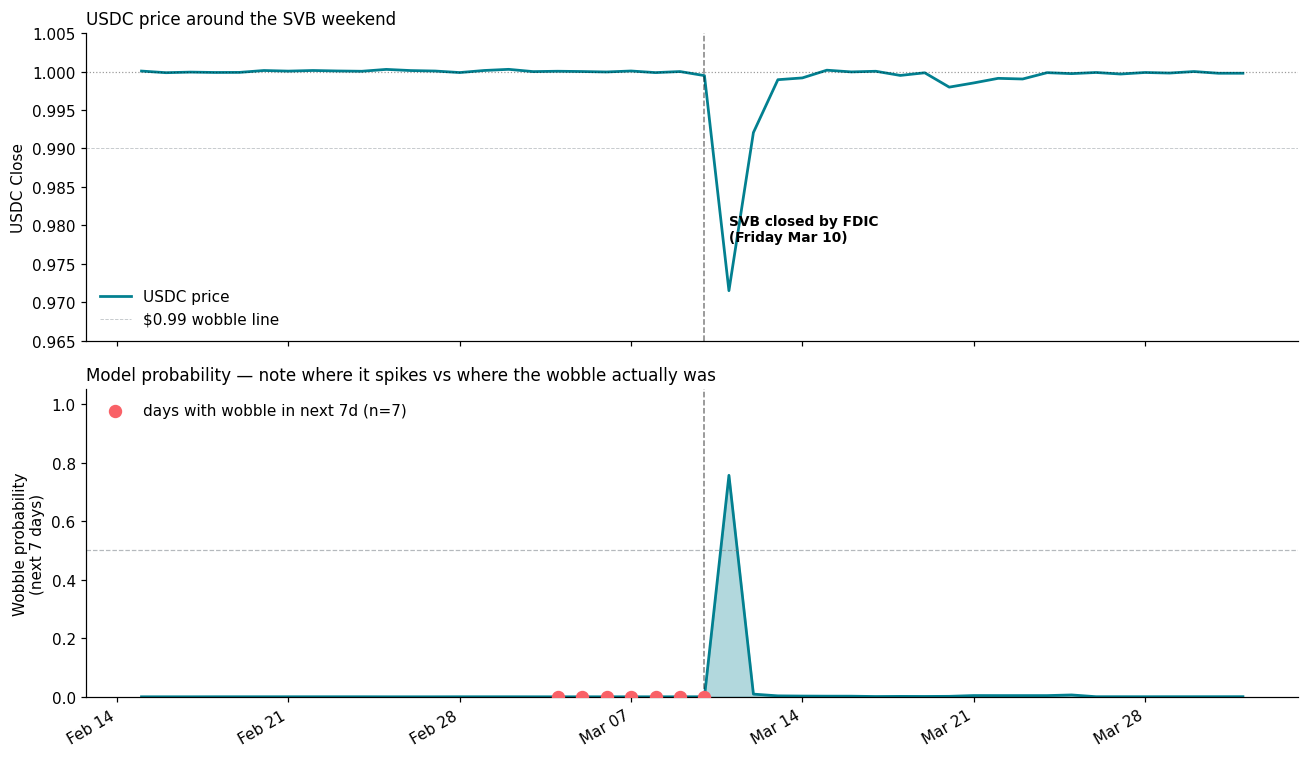

USDC days where y_wobble = 1 (model SHOULD have warned):
      Date    Close  wobble_prob
2023-03-04 1.000048     0.000111
2023-03-05 1.000010     0.000111
2023-03-06 0.999953     0.000111
2023-03-07 1.000081     0.000111
2023-03-08 0.999869     0.000111
2023-03-09 1.000008     0.000111
2023-03-10 0.999479     0.000183

USDC days where wobble_prob > 0.5 (model DID warn):
      Date  Close  y_wobble  wobble_prob
2023-03-11 0.9715         0     0.756392


In [27]:
# ============================================================
# USDC: zoom into March 2023 (SVB weekend)
# ============================================================
usdc = oos[oos.Coin == 'USDC'].sort_values('Date').reset_index(drop=True)
mar2023 = usdc[(usdc.Date >= '2023-02-15') & (usdc.Date <= '2023-04-01')]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1]})

# --- Top: USDC price ---
ax = axes[0]
ax.plot(mar2023.Date, mar2023.Close, color=TEAL, linewidth=1.8, label='USDC price')
ax.axhline(1.00, color='black', linestyle=':', alpha=0.4, linewidth=0.8)
ax.axhline(0.99, color=GRAY, linestyle='--', alpha=0.4, linewidth=0.6, label='\$0.99 wobble line')
ax.axvline(pd.Timestamp('2023-03-10'), color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2023-03-11'), 0.978, 'SVB closed by FDIC\n(Friday Mar 10)',
        fontsize=9, fontweight='bold')
ax.set_ylim(0.965, 1.005)
ax.set_ylabel('USDC Close', fontsize=10)
ax.set_title('USDC price around the SVB weekend', fontsize=11, loc='left')
ax.legend(loc='lower left', frameon=False)

# --- Bottom: wobble probability ---
ax = axes[1]
ax.fill_between(mar2023.Date, 0, mar2023.wobble_prob, color=TEAL, alpha=0.3)
ax.plot(mar2023.Date, mar2023.wobble_prob, color=TEAL, linewidth=1.8)
# Highlight the days that *had* a wobble in the next 7 (true positives we should catch)
true_pos = mar2023[mar2023.y_wobble == 1]
ax.scatter(true_pos.Date, true_pos.wobble_prob, color=CORAL, s=60, zorder=5,
           label=f'days with wobble in next 7d (n={len(true_pos)})')
ax.axhline(0.5, color=GRAY, linestyle='--', alpha=0.5, linewidth=0.8)
ax.axvline(pd.Timestamp('2023-03-10'), color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Wobble probability\n(next 7 days)', fontsize=10)
ax.set_title('Model probability — note where it spikes vs where the wobble actually was',
             fontsize=11, loc='left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

# The diagnostic: where were the labels vs where were the high probabilities?
print('USDC days where y_wobble = 1 (model SHOULD have warned):')
print(true_pos[['Date', 'Close', 'wobble_prob']].to_string(index=False))
print('\nUSDC days where wobble_prob > 0.5 (model DID warn):')
warn = mar2023[mar2023.wobble_prob > 0.5]
print(warn[['Date', 'Close', 'y_wobble', 'wobble_prob']].to_string(index=False) if len(warn)
      else '  (none)')


**What you should see — the painful truth:**

- The labels (`y_wobble = 1`) sit on the **week BEFORE** the visible depeg. On those days, USDC's price was \$1.0000 and every feature looked normal. **The model gave them low probabilities.** It had no way to know.
- The model's probability *finally* spikes on **March 11-12** — *after* the depeg is visible. That's not prediction; that's recognizing the obvious. By then USDC has already broken \$0.99 and traders already saw it.

### Why no price-only model could have caught this

USDC depegged because of an **exogenous shock**: SVB failed Friday March 10, 2023. Circle had \$3.3B parked there. That's a fact about a *bank*, not a fact about the *coin's price history*. Until that information leaked into prices, no time-series feature on USDC could possibly carry the signal.

This is the **Lopez de Prado warning** in concrete form: ML models predict the future from the past. Some catastrophes have informative pasts (UST: years of fragile mechanism design + escalating wobbles). Others have no informative past at all (USDC: stable for years, then a regional bank failed).

### The taxonomy

| Failure mode | Predictable from price? | Example |
|--------------|--------------------------|---------|
| **Algorithmic / mechanism collapse** | Often yes — escalating wobbles, abnormal trading patterns | UST May 2022 |
| **Reserve / banking shock** | No — exogenous event, no warning in price | USDC March 2023, USDT (any future banking issue) |
| **Smart contract exploit** | No — code bug exposed instantly | Iron Finance 2021 |
| **Regulatory action** | Sometimes — depends on how telegraphed | BUSD / Paxos Feb 2023 |

A useful stablecoin risk system would combine our price-based ML model with **alt data**: bank exposure feeds, regulatory filings, on-chain reserve attestations, governance proposals. (Recall Week 7's Alt Data lab — this is where it would slot in.)

---


## Part 8: Questions for William (~3 min)

You've now done what an outside risk modeler could have done with public price data — and you've seen its limits. **You are about to talk to someone who saw it from the inside.**

### Five questions worth asking

1. **The week before.** Our price-based model had no warning before May 9. From inside Terra, what *did* you see in the days/weeks before? Was there an internal "uh oh" moment, and how early was it?

2. **The mechanism vs the bank run.** The Terra design assumed LUNA's market cap would always be large enough to absorb UST redemptions. When that broke, was it a *mechanism* failure (the math didn't work) or a *coordination* failure (everyone ran at once)? Is the distinction even meaningful in retrospect?

3. **Anchor Protocol's 19.5%.** Anchor was paying 19.5% APY on UST deposits — clearly a subsidy. Did the team see Anchor as customer acquisition (worth the burn) or as a hidden run risk (deposits would flee the moment yields dropped)? When did the framing change?

4. **What you'd want to monitor now.** If you were designing a depeg early-warning system today — for any algorithmic stablecoin — what *non-price* signals would you watch most closely? On-chain liquidity? Governance forum sentiment? Specific wallet movements?

5. **Building stable systems.** After Terra, do you think a *purely* algorithmic stablecoin can ever be safe at scale, or does the design space inherently bottom out at "some real reserves required"? Where do you draw that line?

### And one bonus question, if there's time

> Looking back, what's the one thing you wish *outside* observers — academics, regulators, traders — had been able to see clearly at the time, that they couldn't?

---

## Wrap-up

You built a real ML pipeline today: kitchen-sink features, walk-forward validation, honest evaluation that distinguished aggregate metrics from per-coin truth. You discovered that **price-based ML can detect ongoing depegs but not predict their onset**, and that the *kind* of stablecoin matters enormously for whether ML can help at all.

Bring these findings to the conversation with William. The best questions are the ones that test your model against his lived experience.


---

## Answers from Lab Analysis

**1.** Our model showed zero predictive signal until May 9. The absence of warning in price data suggests the collapse either had no observable precursor or occurred too rapidly for market signals to emerge. **Key point:** Price-based features were unable to detect the mechanism failure in advance.

**2.** The mathematics of Terra's design assumed LUNA's market cap would always absorb UST redemptions. The collapse to $0.0065 indicates total confidence loss in that assumption.

**3.** A 19.5% yield on a stablecoin is unsustainable without ongoing capital subsidy. This yield structure reveals either a temporary growth cost or an embedded structural vulnerability. The risk assessment depends on which framing was operational when the yield was introduced.

**4.** Price-based detection fails for prediction. An effective depeg early-warning system would require non-price data: on-chain liquidity metrics, reserve levels, governance forum activity, or specific transaction patterns. The information needed to predict depegs exists outside of price aggregates.

**5.** Pure algorithmic stabilization at scale faces a fundamental constraint: stability requires unbroken confidence, but confidence is fragile and non-recoverable once broken. The design question becomes: What minimum reserve threshold prevents this failure mode? Hybrid approaches (reserves + algorithmic components) may be more defensible than pure mechanisms.

**BONUS.** The observable signal that external observers could have tracked: structural reserve depletion. On-chain data—particularly changes in LUNA supply and Terra reserve levels—would have revealed the mechanism's capacity constraint. This data existed but required specialized monitoring beyond standard price analysis.